# Monte Carlo Option Pricer — Fase 3: opzioni esotiche e greeks

Finora ogni payoff dipendeva solo dal prezzo finale $S_T$. Le **opzioni esotiche path-dependent** guardano invece l'intera traiettoria $S_{t_1}, \dots, S_{t_n}$: per prezzarle bisogna simulare tutti i prezzi intermedi, non solo quello a scadenza.

**Opzione asiatica** (media aritmetica): $A = \frac{1}{n}\sum_{i=1}^{n} S_{t_i}$, payoff della call $\max(A - K, 0)$. È diffusa su materie prime e valute: la media è meno volatile di un singolo prezzo e più difficile da manipolare il giorno della scadenza. Non ha formula chiusa, perché una somma di lognormali non è lognormale.

**Opzione con barriera**: una call o put che *muore* (knock-out) o *nasce* (knock-in) se il prezzo tocca una barriera $B$ durante la vita del contratto. Su ogni traiettoria è attiva esattamente una delle due, quindi vale la **parità in-out**: knock-in + knock-out = europea.

> Precisazione da colloquio: se la barriera fosse osservata *in continuo*, sotto GBM esisterebbe una formula chiusa (Merton 1973, Reiner-Rubinstein 1991). I contratti reali la osservano in date discrete, ad esempio le chiusure giornaliere, e per questo caso una formula esatta non c'è.

**Greeks** con differenze finite centrali:

$$\Delta \approx \frac{V(S_0+h) - V(S_0-h)}{2h} \qquad \Gamma \approx \frac{V(S_0+h) - 2V(S_0) + V(S_0-h)}{h^2} \qquad \mathcal{V} \approx \frac{V(\sigma+k) - V(\sigma-k)}{2k}$$

Il problema è il rumore: $V(S_0+h)$ e $V(S_0-h)$ sono due stime Monte Carlo di numeri vicinissimi, e dividendo per $2h$ (o per $h^2$) il loro errore statistico esplode. La soluzione sono i **Common Random Numbers (CRN)**: simulare tutti i prezzi perturbati con gli *stessi* shock $Z$, cioè lo stesso seed. Poiché

$$\text{Var}(X - Y) = \text{Var}(X) + \text{Var}(Y) - 2\,\text{Cov}(X, Y)$$

e con gli stessi $Z$ la covarianza è altissima, nella differenza il rumore quasi si annulla.

**Architettura.** Il motore Monte Carlo non cambia: le esotiche sono nuove classi con lo stesso metodo `payoff(paths)`, i greeks un modulo nuovo che riusa `discounted_payoffs`.

| Modulo | Responsabilità | Novità della Fase 3 |
|---|---|---|
| `models.py` | *come* si muove il sottostante | — |
| `instruments.py` | *cosa* paga il contratto | `AsianOption`, `BarrierOption` |
| `monte_carlo.py` | prezzo stimato | — |
| `black_scholes.py` | prezzo esatto | `black_scholes_greeks`, riferimento per validare i greeks |
| `validation.py` | confronto Monte Carlo vs Black-Scholes | — |
| `greeks.py` *(nuovo)* | sensibilità del prezzo | `compute_greeks` |

## 0. Setup

In [1]:
# Rende importabile il package option_pricer, sia su Colab sia in locale
import subprocess
import sys
from pathlib import Path

REPO_URL = "https://github.com/FedeDiCandia/monte-carlo-option-pricer.git"
IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    # Su Colab il progetto non c'è: lo scarica da GitHub, una volta per sessione
    PROJECT_DIR = Path("/content/monte-carlo-option-pricer")
    if not PROJECT_DIR.exists():
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, str(PROJECT_DIR)], check=True)
else:
    # In locale il notebook sta in notebooks/, il package nella cartella superiore
    PROJECT_DIR = Path.cwd().parent

# Controllo esplicito: senza, un percorso sbagliato farebbe fallire gli import della cella dopo con un errore poco chiaro
if not (PROJECT_DIR / "option_pricer" / "plotting.py").is_file():
    raise FileNotFoundError(
        f"Package option_pricer non trovato in {PROJECT_DIR}. "
        "Su Colab: Runtime → Disconnetti ed elimina runtime, poi esegui di nuovo tutto. "
        "In locale: apri il notebook dalla cartella notebooks/ del progetto."
    )

sys.path.insert(0, str(PROJECT_DIR))
print("Package option_pricer pronto.")

Package option_pricer pronto.


In [2]:
import numpy as np
import matplotlib.pyplot as plt

from option_pricer import (
    GBM, EuropeanCall, EuropeanPut, AsianOption, BarrierOption,
    black_scholes_greeks, compare_with_black_scholes, compute_greeks,
    price_black_scholes, price_monte_carlo,
)
from option_pricer.plotting import BLACK, FILL, LIGHT, MID, SERIES, add_caption, apply_style, math_int

# Stile grafico accademico comune a tutti i notebook: font serif, riquadro con tacche interne, scala di grigi
apply_style()

## 1. Parametri

In [3]:
# --- Mercato (modello) ---
S0 = 100.0      # prezzo spot del sottostante oggi
r = 0.05        # tasso risk-free annuo, capitalizzazione continua
sigma = 0.20    # volatilità annua

# --- Contratti ---
K = 100.0       # strike comune a tutte le opzioni (at-the-money)
T = 1.0         # scadenza in anni
B_UP = 130.0    # barriera sopra lo spot (+30%), per le call up-and-out / up-and-in
B_DOWN = 80.0   # barriera sotto lo spot (-20%), per le put down-and-out / down-and-in

# --- Numerici (motore) ---
N = 100_000     # traiettorie; ognuna ha 253 prezzi -> 100.000 × 253 × 8 byte ≈ 200 MB per matrice
N_STEPS = 252   # un passo per giorno di borsa = date di osservazione di media e barriera
SEED = 42       # seme casuale: stessi numeri a ogni esecuzione

model = GBM(S0=S0, r=r, sigma=sigma)

european_call = EuropeanCall(K=K, T=T)
european_put = EuropeanPut(K=K, T=T)
asian_call = AsianOption(K=K, T=T, kind="call")
asian_put = AsianOption(K=K, T=T, kind="put")
up_out_call = BarrierOption(K=K, T=T, barrier=B_UP, kind="call", direction="up", knock="out")
up_in_call = BarrierOption(K=K, T=T, barrier=B_UP, kind="call", direction="up", knock="in")
down_out_put = BarrierOption(K=K, T=T, barrier=B_DOWN, kind="put", direction="down", knock="out")
down_in_put = BarrierOption(K=K, T=T, barrier=B_DOWN, kind="put", direction="down", knock="in")

## 2. Perché serve l'intera traiettoria

Con `n_steps = 1`, il default del motore e sufficiente per le europee, la matrice delle traiettorie ha due sole colonne: $S_0$ e $S_T$. Per un'asiatica la "media" sarebbe il solo $S_T$, quindi l'opzione diventerebbe un'europea. Per una barriera vedremmo solo se $S_T$ sta oltre $B$, ignorando ogni attraversamento durante la vita.

Il risultato sarebbe sbagliato **senza alcun errore visibile**. Per questo le classi esotiche rifiutano esplicitamente le matrici con meno di 2 passi.

In [4]:
# (a) Con il default n_steps = 1 le esotiche si rifiutano di calcolare un payoff sbagliato
for contract in [asian_call, up_out_call]:
    try:
        price_monte_carlo(model, contract, n_paths=N, seed=SEED)
    except ValueError as err:
        print(f"{type(contract).__name__}: {err}")

# (b) Black-Scholes non ha una formula per questi contratti
try:
    price_black_scholes(model, asian_call)
except TypeError as err:
    print(f"\nBlack-Scholes: {err}")

# (c) Cosa succederebbe senza il controllo: con un solo passo la "media" coincide con S_T,
#     quindi l'asiatica pagherebbe esattamente come l'europea
paths_1 = model.simulate_paths(T=T, n_steps=1, n_paths=N, rng=np.random.default_rng(SEED))
average_1 = paths_1[:, 1:].mean(axis=1)
print(f"\nCon n_steps = 1, la media coincide con S_T su tutte le traiettorie? {np.array_equal(average_1, paths_1[:, -1])}")

AsianOption: AsianOption dipende dall'intera traiettoria: simula con n_steps > 1 (ricevuto n_steps = 1)
BarrierOption: BarrierOption dipende dall'intera traiettoria: simula con n_steps > 1 (ricevuto n_steps = 1)

Black-Scholes: Nessuna formula chiusa per AsianOption: usa price_monte_carlo

Con n_steps = 1, la media coincide con S_T su tutte le traiettorie? True


### Il prezzo delle esotiche dipende da `n_steps`

Per un'europea la GBM è simulata in modo esatto, quindi il numero di passi non cambia il prezzo. Per le esotiche sì, perché `n_steps` stabilisce **quando** si osserva il prezzo: è una clausola del contratto, non un parametro numerico. Rifacciamo il pricing con osservazioni semestrali, trimestrali, mensili, settimanali e giornaliere. Ci aspettiamo:

- **europea**: piatta, entro l'errore statistico;
- **asiatica**: scende, perché la media include sempre più prezzi vicini a oggi, che hanno avuto meno tempo per disperdersi;
- **up-and-out**: scende, perché più date di osservazione catturano più attraversamenti della barriera. Con osservazione continua costerebbe ancora meno.

n_steps                               2        4       12       52      252


Call europea                    10.4662  10.4709  10.4432  10.5190  10.4829


Call asiatica                    8.0970   6.9725   6.1589   5.8625   5.7932


Call up-and-out (B = 130)        5.0732   4.7131   4.2170   3.8069   3.5645


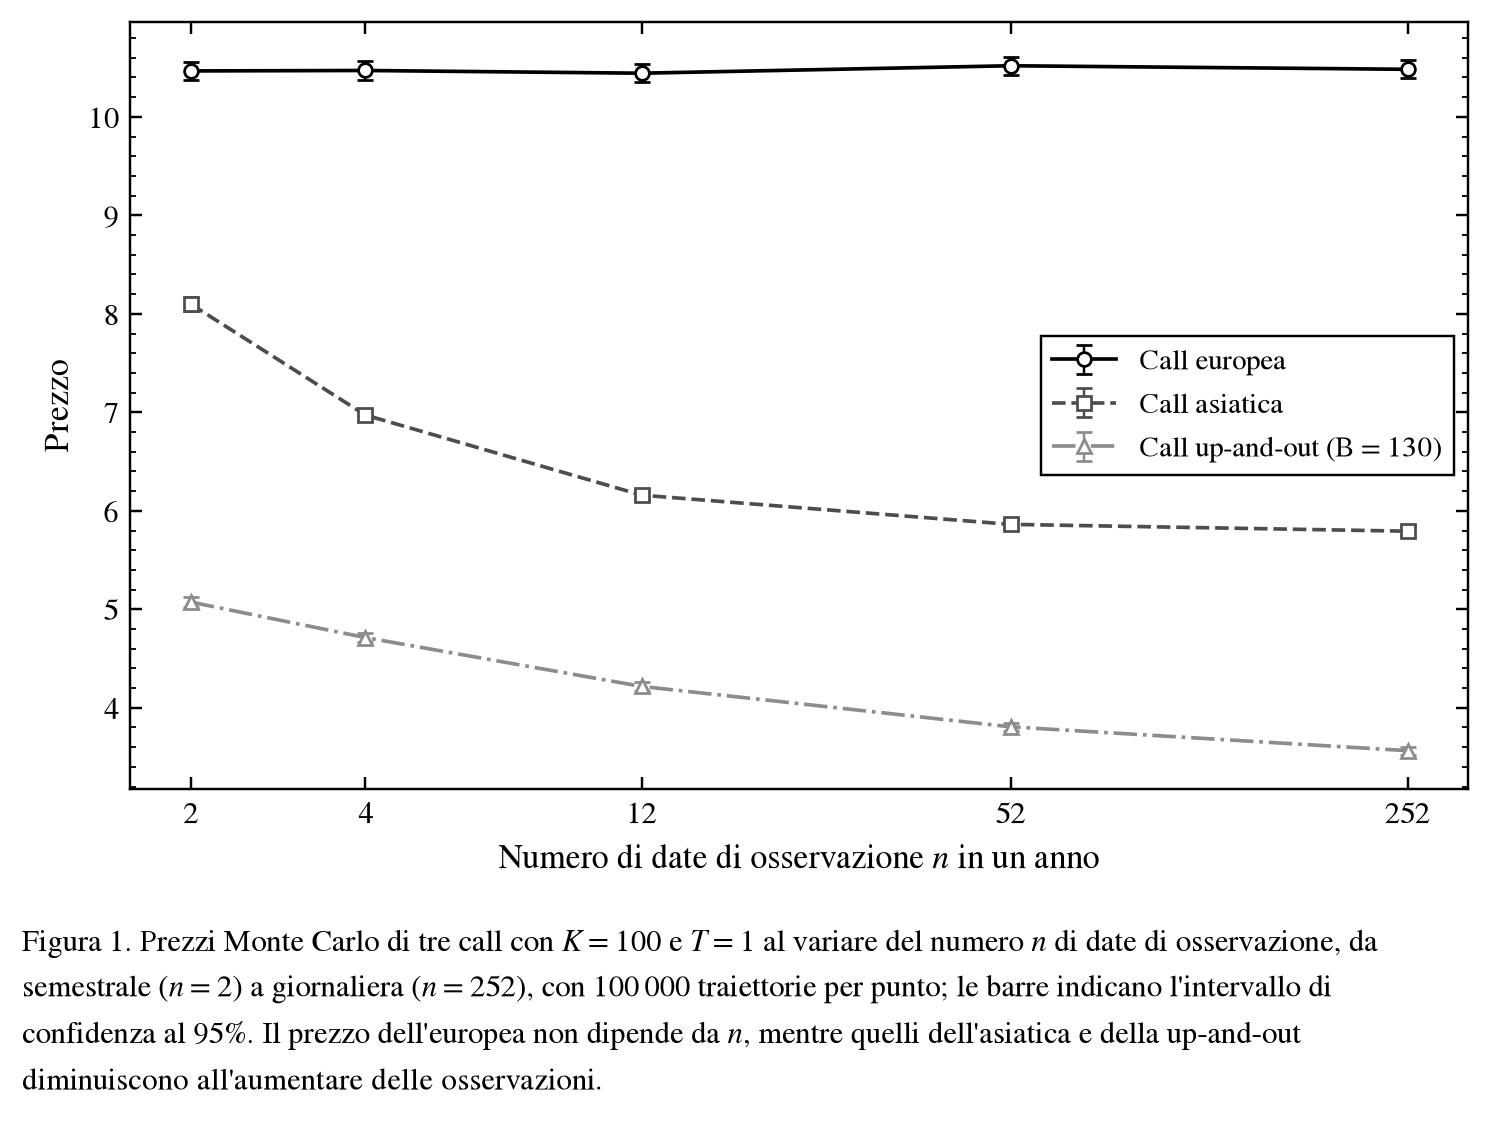

In [5]:
# Frequenze di osservazione: semestrale, trimestrale, mensile, settimanale, giornaliera
steps_grid = [2, 4, 12, 52, 252]

contracts = [
    ("Call europea", european_call),
    ("Call asiatica", asian_call),
    (f"Call up-and-out (B = {B_UP:g})", up_out_call),
]

print(f"{'n_steps':<30}" + "".join(f"{n:>9}" for n in steps_grid))
fig, ax = plt.subplots()
for (label, contract), style in zip(contracts, SERIES):
    results = [price_monte_carlo(model, contract, n_paths=N, n_steps=n, seed=SEED) for n in steps_grid]
    prices_by_steps = np.array([res.price for res in results])
    half_widths = np.array([res.ci_high - res.price for res in results])  # semi-ampiezza IC 95%
    print(f"{label:<30}" + "".join(f"{p:>9.4f}" for p in prices_by_steps))

    # Ogni serie ha il suo tipo di linea e marcatore (SERIES): leggibile anche in bianco e nero
    ax.errorbar(steps_grid, prices_by_steps, yerr=half_widths, capsize=2.5, elinewidth=0.8,
                markerfacecolor="white", markeredgewidth=0.9, label=label, **style)

ax.set_xscale("log")
ax.set_xticks(steps_grid, [str(n) for n in steps_grid])
ax.xaxis.set_minor_locator(plt.NullLocator())
ax.set(xlabel=r"Numero di date di osservazione $n$ in un anno", ylabel="Prezzo")
ax.legend(loc="center right")
fig.tight_layout()
add_caption(fig, 1,
    f"Prezzi Monte Carlo di tre call con $K={K:g}$ e $T={T:g}$ al variare del numero $n$ di date di osservazione, "
    f"da semestrale ($n=2$) a giornaliera ($n=252$), con {math_int(N)} traiettorie per punto; le barre indicano "
    f"l'intervallo di confidenza al 95%. Il prezzo dell'europea non dipende da $n$, mentre quelli dell'asiatica "
    f"e della up-and-out diminuiscono all'aumentare delle osservazioni.")
plt.show()

## 3. Prezzi delle esotiche (osservazione giornaliera)

Tutti i contratti sono prezzati sulle stesse traiettorie (stesso seed, stesso `n_steps`). Due controlli senza bisogno di formule:

- **Parità in-out**: knock-out + knock-in deve dare esattamente l'europea, a meno dell'arrotondamento, perché su ogni traiettoria una sola delle due è attiva.
- **L'europea simulata a 252 passi** deve restare coerente con Black-Scholes: più passi non devono introdurre errori.

In [6]:
book = {
    "Call europea": european_call,
    "Call asiatica": asian_call,
    "Call up-and-out": up_out_call,
    "Call up-and-in": up_in_call,
    "Put europea": european_put,
    "Put asiatica": asian_put,
    "Put down-and-out": down_out_put,
    "Put down-and-in": down_in_put,
}

prices = {}
for label, contract in book.items():
    prices[label] = price_monte_carlo(model, contract, n_paths=N, n_steps=N_STEPS, seed=SEED)
    print(f"{label:<18}{prices[label]}")

# Parità in-out: stesse traiettorie -> la somma dei prezzi coincide con l'europea
call_gap = prices["Call up-and-out"].price + prices["Call up-and-in"].price - prices["Call europea"].price
put_gap = prices["Put down-and-out"].price + prices["Put down-and-in"].price - prices["Put europea"].price
print(f"\nParità in-out:  call (out + in - europea) = {call_gap:.1e}   put (out + in - europea) = {put_gap:.1e}")

print(f"Call europea a {N_STEPS} passi vs Black-Scholes:  {compare_with_black_scholes(model, european_call, n_paths=N, n_steps=N_STEPS, seed=SEED)}")

Call europea      10.4829 ± 0.0469 (SE)  |  IC 95%: [10.3909, 10.5748]  |  N = 100,000


Call asiatica     5.7932 ± 0.0254 (SE)  |  IC 95%: [5.7434, 5.8430]  |  N = 100,000


Call up-and-out   3.5645 ± 0.0202 (SE)  |  IC 95%: [3.5250, 3.6041]  |  N = 100,000


Call up-and-in    6.9183 ± 0.0478 (SE)  |  IC 95%: [6.8246, 7.0120]  |  N = 100,000


Put europea       5.5676 ± 0.0274 (SE)  |  IC 95%: [5.5140, 5.6213]  |  N = 100,000


Put asiatica      3.3604 ± 0.0167 (SE)  |  IC 95%: [3.3278, 3.3931]  |  N = 100,000


Put down-and-out  1.7551 ± 0.0123 (SE)  |  IC 95%: [1.7311, 1.7791]  |  N = 100,000


Put down-and-in   3.8125 ± 0.0271 (SE)  |  IC 95%: [3.7595, 3.8656]  |  N = 100,000

Parità in-out:  call (out + in - europea) = 0.0e+00   put (out + in - europea) = 0.0e+00


Call europea a 252 passi vs Black-Scholes:  MC 10.4829 ± 0.0469  |  BS 10.4506  |  scarto +0.0323 = +0.69 SE  |  BS dentro l'IC 95%


## 4. Asiatica vs europea

La call asiatica costa molto meno dell'europea con lo stesso strike, perché paga su una variabile **meno dispersa**. La media $A$ smussa gli estremi: per ottenere un payoff alto non basta che il prezzo sia alto a scadenza, deve esserlo in media lungo tutto l'anno.

Con media continua la varianza di $\ln A$ è circa $\sigma^2 T / 3$: l'asiatica si comporta grosso modo come un'europea con volatilità $\sigma/\sqrt{3} \approx 11{,}5\%$ invece del 20%. Anche la media di $A$ è un po' più bassa di quella di $S_T$, perché include prezzi osservati presto, quando il drift $r$ ha agito per meno tempo.

Da notare nei numeri: la probabilità di finire sopra lo strike è quasi la stessa per le due opzioni. A cambiare è **di quanto** si finisce sopra.

Prezzo call:        europea = 10.4829   asiatica = 5.7932  (55% dell'europea)
Media:              S_T = 105.17   A = 102.56
Dev. std:           S_T =  21.33   A =  12.04
Vol. del logaritmo: ln S_T = 20.0%   ln A = 11.6%   (σ/√3 = 11.5%)
P(sopra lo strike): S_T > K = 56.0%   A > K = 55.8%


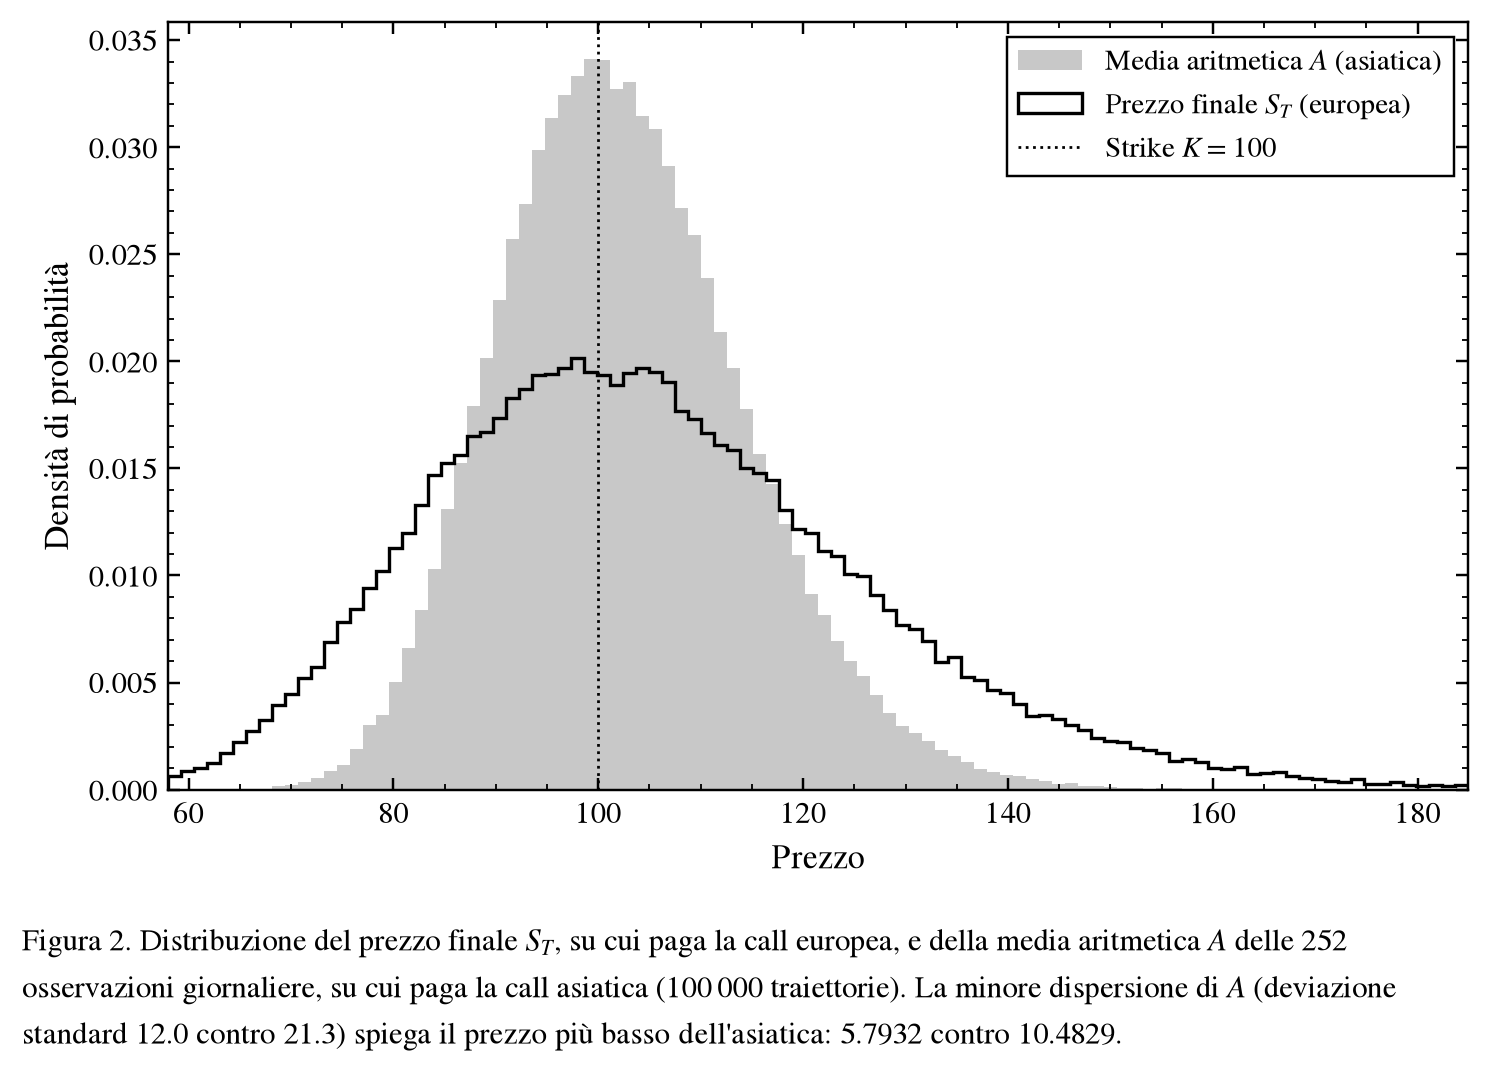

In [7]:
# Le stesse traiettorie usate per i prezzi della sezione 3 (stesso seed, stessi passi)
paths = model.simulate_paths(T=T, n_steps=N_STEPS, n_paths=N, rng=np.random.default_rng(SEED))
S_T = paths[:, -1]                  # ciò che guarda l'europea
A = paths[:, 1:].mean(axis=1)       # ciò che guarda l'asiatica

european_price, asian_price = prices["Call europea"].price, prices["Call asiatica"].price
print(f"Prezzo call:        europea = {european_price:.4f}   asiatica = {asian_price:.4f}  ({asian_price / european_price:.0%} dell'europea)")
print(f"Media:              S_T = {S_T.mean():6.2f}   A = {A.mean():6.2f}")
print(f"Dev. std:           S_T = {S_T.std(ddof=1):6.2f}   A = {A.std(ddof=1):6.2f}")
print(f"Vol. del logaritmo: ln S_T = {np.log(S_T).std(ddof=1) / np.sqrt(T):.1%}   ln A = {np.log(A).std(ddof=1) / np.sqrt(T):.1%}   (σ/√3 = {sigma / np.sqrt(3):.1%})")
print(f"P(sopra lo strike): S_T > K = {np.mean(S_T > K):.1%}   A > K = {np.mean(A > K):.1%}")

bins = np.linspace(np.quantile(S_T, 0.002), np.quantile(S_T, 0.998), 101)
# Densità normalizzata su TUTTE le N traiettorie, anche quelle fuori dal range del grafico
weights = np.full(N, 1 / (N * (bins[1] - bins[0])))

fig, ax = plt.subplots()
ax.hist(A, bins=bins, weights=weights, histtype="stepfilled", color=LIGHT, label=r"Media aritmetica $A$ (asiatica)")
ax.hist(S_T, bins=bins, weights=weights, histtype="step", color=BLACK, linewidth=1.1, label=r"Prezzo finale $S_T$ (europea)")
ax.axvline(K, color=BLACK, linewidth=0.9, linestyle=":", label=rf"Strike $K={K:g}$")
ax.set_xlim(bins[0], bins[-1])
ax.set_ylim(bottom=0)
ax.set(xlabel="Prezzo", ylabel="Densità di probabilità")
ax.legend(loc="upper right")
fig.tight_layout()
add_caption(fig, 2,
    f"Distribuzione del prezzo finale $S_T$, su cui paga la call europea, e della media aritmetica $A$ delle "
    f"{N_STEPS} osservazioni giornaliere, su cui paga la call asiatica ({math_int(N)} traiettorie). La minore "
    f"dispersione di $A$ (deviazione standard {A.std(ddof=1):.1f} contro {S_T.std(ddof=1):.1f}) spiega il prezzo "
    f"più basso dell'asiatica: {asian_price:.4f} contro {european_price:.4f}.")
plt.show()

## 5. Barriera: il payoff dipende dal percorso

Call up-and-out con $K = 100$ e $B = 130$: paga $\max(S_T - K, 0)$ solo se il prezzo non ha **mai** toccato 130.

- **A sinistra**: due traiettorie che finiscono quasi allo stesso prezzo. Quella che non ha mai toccato la barriera paga $S_T - K$; quella che l'ha toccata è morta in quel momento e paga 0, anche se poi è ridiscesa.
- **A destra**: payoff contro $S_T$ per 5.000 traiettorie. Per un'europea ogni $S_T$ dà un solo payoff (la linea "a gomito"). Per la barriera, lo stesso $S_T$ tra $K$ e $B$ può dare due payoff diversi: il payoff non è una funzione di $S_T$, ma dell'intero percorso.

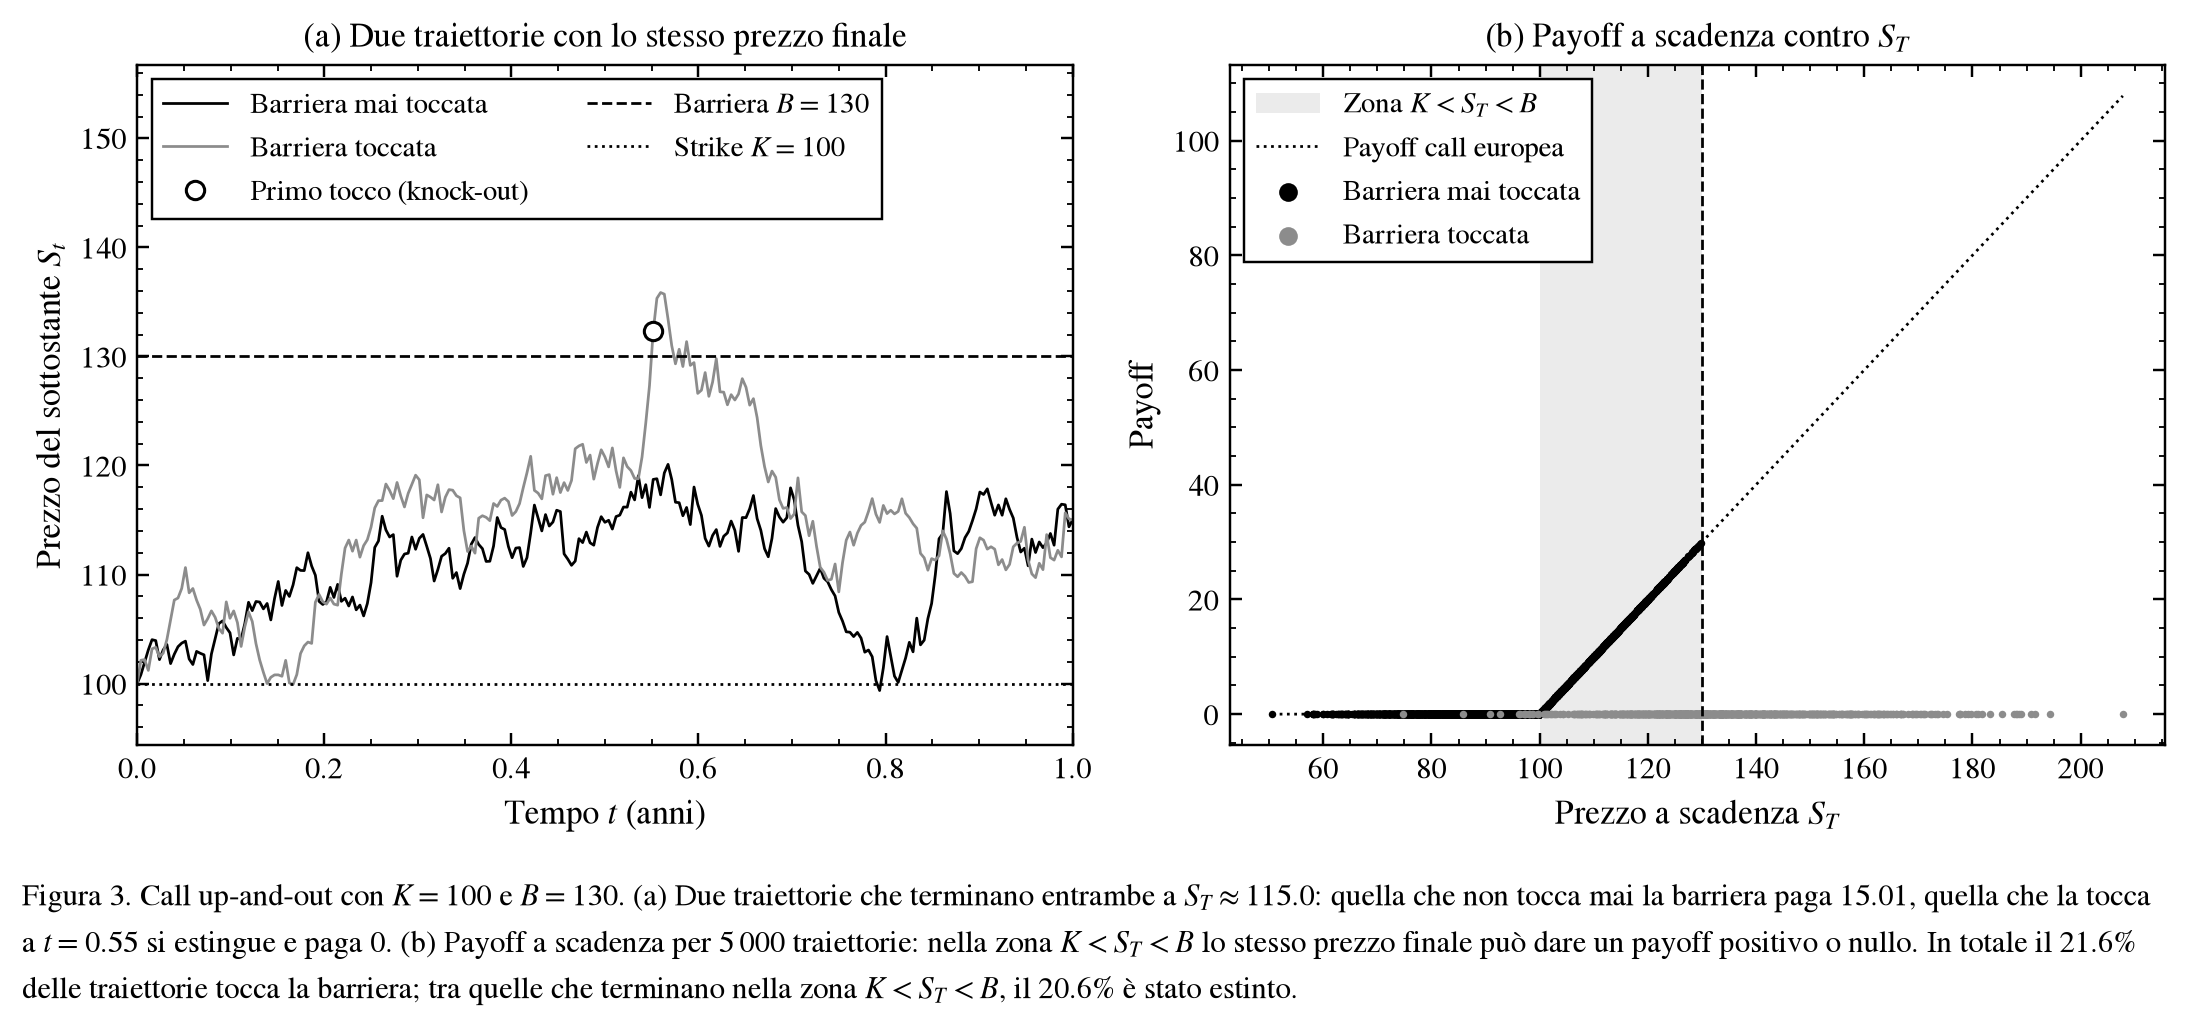

Traiettorie che toccano la barriera: 21.6%
Tra quelle con K < S_T < B, dove l'europea paga: 20.6% sono state disattivate


In [8]:
hit = up_out_call.touched(paths)          # True se la traiettoria ha toccato la barriera
payoff_uo = up_out_call.payoff(paths)
between = (S_T > K) & (S_T < B_UP)        # dove l'europea paga ma la barriera può averla estinta

# Una traiettoria estinta che finisce vicino a 115, e quella attiva con il prezzo finale più simile
ko_idx = np.flatnonzero(hit)[np.argmin(np.abs(S_T[hit] - 115.0))]
alive_idx = np.flatnonzero(~hit)[np.argmin(np.abs(S_T[~hit] - S_T[ko_idx]))]
first_touch = np.argmax(paths[ko_idx] >= B_UP)   # indice del primo passo oltre la barriera
t = np.linspace(0, T, N_STEPS + 1)

fig, (ax_paths, ax_payoff) = plt.subplots(1, 2, figsize=(10, 4))

# --- (a) Due traiettorie con lo stesso prezzo finale ---
ax_paths.plot(t, paths[alive_idx], color=BLACK, linewidth=0.9, label="Barriera mai toccata")
ax_paths.plot(t, paths[ko_idx], color=MID, linewidth=0.9, label="Barriera toccata")
ax_paths.plot(t[first_touch], paths[ko_idx, first_touch], "o", color=BLACK, markerfacecolor="white",
              markeredgewidth=1.0, markersize=6, zorder=3, label="Primo tocco (knock-out)")
ax_paths.axhline(B_UP, color=BLACK, linewidth=0.9, linestyle="--", label=rf"Barriera $B={B_UP:g}$")
ax_paths.axhline(K, color=BLACK, linewidth=0.9, linestyle=":", label=rf"Strike $K={K:g}$")
y_low = min(paths[[alive_idx, ko_idx]].min(), K) - 5
ax_paths.set_ylim(y_low, B_UP + 0.75 * (B_UP - y_low))  # spazio in alto per la legenda
ax_paths.set_xlim(0, T)
ax_paths.set_title("(a) Due traiettorie con lo stesso prezzo finale")
ax_paths.set(xlabel=r"Tempo $t$ (anni)", ylabel=r"Prezzo del sottostante $S_t$")
ax_paths.legend(loc="upper left", ncol=2)

# --- (b) Payoff a scadenza contro S_T per un campione di traiettorie ---
sample = slice(0, 5_000)
S_s, pay_s, hit_s = S_T[sample], payoff_uo[sample], hit[sample]
x = np.linspace(S_s.min(), S_s.max(), 400)
ax_payoff.axvspan(K, B_UP, color=FILL, linewidth=0, zorder=0, label=r"Zona $K<S_T<B$")
ax_payoff.plot(x, np.maximum(x - K, 0.0), color=BLACK, linewidth=0.9, linestyle=":", zorder=1, label="Payoff call europea")
ax_payoff.scatter(S_s[~hit_s], pay_s[~hit_s], s=6, color=BLACK, linewidths=0, zorder=2, label="Barriera mai toccata")
ax_payoff.scatter(S_s[hit_s], pay_s[hit_s], s=6, color=MID, linewidths=0, zorder=2, label="Barriera toccata")
ax_payoff.axvline(B_UP, color=BLACK, linewidth=0.9, linestyle="--")
ax_payoff.set_title(r"(b) Payoff a scadenza contro $S_T$")
ax_payoff.set(xlabel=r"Prezzo a scadenza $S_T$", ylabel="Payoff")
ax_payoff.legend(loc="upper left", markerscale=2.5)

fig.tight_layout()
add_caption(fig, 3,
    rf"Call up-and-out con $K={K:g}$ e $B={B_UP:g}$. (a) Due traiettorie che terminano entrambe a "
    rf"$S_T\approx{S_T[ko_idx]:.1f}$: quella che non tocca mai la barriera paga {payoff_uo[alive_idx]:.2f}, "
    rf"quella che la tocca a $t={t[first_touch]:.2f}$ si estingue e paga 0. (b) Payoff a scadenza per "
    rf"{math_int(5_000)} traiettorie: nella zona $K<S_T<B$ lo stesso prezzo finale può dare un payoff positivo "
    rf"o nullo. In totale il {hit.mean():.1%} delle traiettorie tocca la barriera; tra quelle che terminano "
    rf"nella zona $K<S_T<B$, il {hit[between].mean():.1%} è stato estinto.")
plt.show()

print(f"Traiettorie che toccano la barriera: {hit.mean():.1%}")
print(f"Tra quelle con K < S_T < B, dove l'europea paga: {hit[between].mean():.1%} sono state disattivate")

## 6. Greeks con differenze finite

`compute_greeks` perturba $S_0$ di $h = 1\%$ (cioè di 1,00) e $\sigma$ di $k = $ 1 punto di volatilità, riprezza con lo **stesso seed** e applica le differenze finite traiettoria per traiettoria. Così ottiene per ogni greek anche un errore standard. Unità:

- **Delta**: variazione del prezzo per +1 sul sottostante;
- **Gamma**: variazione del delta per +1 sul sottostante;
- **Vega**: variazione del prezzo per +1,00 di volatilità (per 1 punto di vol si divide per 100).

### 6.1 Validazione su un'europea

Dove Black-Scholes dà i greeks esatti ($\Delta = N(d_1)$, $\Gamma = \varphi(d_1) / (S_0 \sigma \sqrt{T})$, $\mathcal{V} = S_0 \varphi(d_1) \sqrt{T}$), il Monte Carlo deve ritrovarli entro l'errore, come per i prezzi nella Fase 2.

In [9]:
bs_greeks = black_scholes_greeks(model, european_call)
mc_greeks = compute_greeks(model, european_call, seed=SEED, n_paths=N)   # europea: basta n_steps = 1

print(f"{'':<7}{'Monte Carlo (CRN)':>21}{'Black-Scholes':>15}{'z':>8}")
for name in ["delta", "gamma", "vega"]:
    est = getattr(mc_greeks, name)
    z = (est.value - bs_greeks[name]) / est.std_error
    print(f"{name.capitalize():<7}{est.value:>12.4f} ± {est.std_error:.4f}{bs_greeks[name]:>15.4f}{z:>+8.2f}")

           Monte Carlo (CRN)  Black-Scholes       z
Delta        0.6346 ± 0.0018         0.6368   -1.26
Gamma        0.0186 ± 0.0003         0.0188   -0.34
Vega        37.4718 ± 0.2412        37.5240   -0.22


### 6.2 Quanto rumore tolgono i Common Random Numbers

Stesso calcolo, ma con un seme diverso per ciascuna delle 5 simulazioni. La stima resta corretta in media, però il rumore esplode. Il rapporto tra gli errori standard, al quadrato, dice quante traiettorie in più servirebbero senza CRN per la stessa precisione (l'errore scala come $1/\sqrt{N}$).

In [10]:
no_crn = compute_greeks(model, european_call, seed=SEED, n_paths=N, common_random_numbers=False)

print(f"{'':<7}{'SE con CRN':>12}{'SE senza CRN':>14}{'rapporto':>10}{'traiettorie in più senza CRN':>31}")
for name in ["delta", "gamma", "vega"]:
    se_crn = getattr(mc_greeks, name).std_error
    se_indep = getattr(no_crn, name).std_error
    ratio = se_indep / se_crn
    print(f"{name.capitalize():<7}{se_crn:>12.4f}{se_indep:>14.4f}{ratio:>9.0f}×{ratio**2:>30,.0f}×")

print(f"\nCon CRN:   {mc_greeks}")
print(f"Senza CRN: {no_crn}")

         SE con CRN  SE senza CRN  rapporto   traiettorie in più senza CRN
Delta        0.0018        0.0329       18×                           332×
Gamma        0.0003        0.1140      338×                       114,290×
Vega         0.2412        3.3093       14×                           188×

Con CRN:   Prezzo 10.4205 ± 0.0468  |  Delta 0.6346 ± 0.0018  |  Gamma 0.0186 ± 0.0003  |  Vega 37.4718 ± 0.2412  |  CRN: sì
Senza CRN: Prezzo 10.4205 ± 0.0468  |  Delta 0.5947 ± 0.0329  |  Gamma 0.0551 ± 0.1140  |  Vega 42.4016 ± 3.3093  |  CRN: no


### 6.3 Greeks delle esotiche

Stessa funzione, ma con `n_steps = 252`. Cosa aspettarsi:

- **Asiatica**: delta e vega più bassi dell'europea, perché la media smussa la volatilità. Il gamma invece è **più alto**: con una volatilità effettiva più bassa (circa $\sigma/\sqrt{3}$) la distribuzione è più concentrata attorno allo strike, e lì si concentra anche la convessità. Vale lo stesso per un'europea: at-the-money il gamma cresce quando $\sigma$ scende.
- **Up-and-out**: vega **negativo**. Più volatilità vuol dire più probabilità di toccare la barriera e morire: l'effetto supera il guadagno di valore tipico delle opzioni. Il delta è quasi nullo, perché salire avvicina sia al profitto sia alla barriera.

In [11]:
exotic_book = {
    "Call europea": european_call,
    "Call asiatica": asian_call,
    "Call up-and-out": up_out_call,
}

print(f"{'':<17}{'Prezzo':>17}{'Delta':>17}{'Gamma':>17}{'Vega':>19}")
for label, contract in exotic_book.items():
    g = compute_greeks(model, contract, seed=SEED, n_paths=N, n_steps=N_STEPS)
    print(f"{label:<17}{str(g.price):>17}{str(g.delta):>17}{str(g.gamma):>17}{str(g.vega):>19}")

                            Prezzo            Delta            Gamma               Vega


Call europea      10.4829 ± 0.0469  0.6374 ± 0.0018  0.0185 ± 0.0003   37.7354 ± 0.2423


Call asiatica      5.7932 ± 0.0254  0.5885 ± 0.0016  0.0328 ± 0.0004   21.8411 ± 0.1267


Call up-and-out    3.5645 ± 0.0202  0.0454 ± 0.0059 -0.0090 ± 0.0119  -26.4626 ± 0.5761


### 6.4 Barriere: il compromesso nella scelta di $h$

Il gamma della up-and-out è molto rumoroso. Il payoff è **discontinuo**: toccando la barriera passa di colpo da $S_T - K$ (fino a 30) a 0. Con le CRN, perturbare $S_0$ cambia il payoff solo per le poche traiettorie il cui massimo sta a ridosso della barriera, ma per quelle il salto è enorme, e dividendo per $h^2$ il rumore esplode.

Aumentare $h$ riduce il rumore ma introduce **errore di approssimazione** (la differenza finita approssima peggio la derivata). È il classico compromesso tra bias e varianza:

In [12]:
for bump in [0.01, 0.02, 0.05]:
    g = compute_greeks(model, up_out_call, seed=SEED, n_paths=N, n_steps=N_STEPS, spot_bump=bump)
    print(f"h = {bump:.0%} di S0:   Delta {g.delta}    Gamma {g.gamma}")

h = 1% di S0:   Delta 0.0454 ± 0.0059    Gamma -0.0090 ± 0.0119


h = 2% di S0:   Delta 0.0419 ± 0.0042    Gamma -0.0111 ± 0.0042


h = 5% di S0:   Delta 0.0430 ± 0.0025    Gamma -0.0129 ± 0.0011


## Riepilogo

- **Path dependence resa esplicita.** Con `n_steps = 1` le esotiche si rifiutano di prezzare, perché la "media" sarebbe il solo $S_T$. Il prezzo dipende dalla frequenza di osservazione: da semestrale a giornaliera l'asiatica scende da 8,10 a 5,79 e la up-and-out da 5,07 a 3,56, mentre l'europea resta ferma attorno a 10,5.
- **Prezzi con osservazione giornaliera** (100.000 traiettorie): call europea 10,48, asiatica 5,79, up-and-out 3,56, up-and-in 6,92. La parità in-out è rispettata esattamente, e l'europea a 252 passi resta coerente con Black-Scholes.
- **Asiatica vs europea.** L'asiatica costa il 55% dell'europea: la media $A$ ha deviazione standard 12,0 contro 21,3, con volatilità del logaritmo 11,6%, in linea con $\sigma/\sqrt{3} = 11{,}5\%$.
- **Barriera.** Il 21,6% delle traiettorie tocca 130. Tra quelle che chiudono tra $K$ e $B$, dove l'europea pagherebbe, una su cinque è stata disattivata: stesso $S_T$, payoff diverso.
- **Greeks validati** sull'europea contro le formule esatte di Black-Scholes, tutti con $|z| < 1{,}3$.
- **Common Random Numbers.** Senza CRN l'errore standard è 18 volte più grande per il delta, 338 per il gamma e 14 per il vega. Per la stessa precisione servirebbero da 188 a oltre 100.000 volte le traiettorie.
- **Greeks delle esotiche.** L'asiatica ha delta e vega più bassi e gamma più alto dell'europea. La up-and-out ha vega negativo (−26,5) e delta quasi nullo. Il suo gamma, con payoff discontinuo, richiede un $h$ più grande: è il compromesso tra bias e varianza.